# YEaaaw wassup

In [1]:
#Imports and other relevant stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs

In [2]:
#Importing the data into DataFrames
boredata= pd.read_csv("https://github.com/Matei-Stoica-Uni/CaseStudy_Australia/blob/main/recharge-australia_data-bores.csv?raw=true")
griddata= pd.read_csv("https://github.com/Matei-Stoica-Uni/CaseStudy_Australia/blob/main/recharge-australia_data-gridded.csv?raw=true")

In [3]:
boredata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98568 entries, 0 to 98567
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Bore_ID                 98568 non-null  object 
 1   State                   98568 non-null  object 
 2   Longitude               98568 non-null  float64
 3   Latitude                98568 non-null  float64
 4   Elevation               98568 non-null  float64
 5   Distance_to_coast       98568 non-null  float64
 6   Rainfall                98568 non-null  float64
 7   Seasonal_rainfall_zone  98568 non-null  object 
 8   Runoff_coefficient      98568 non-null  float64
 9   PET                     98568 non-null  float64
 10  NDVI                    98568 non-null  float64
 11  Soil_class              98568 non-null  object 
 12  Clay_fraction           98568 non-null  float64
 13  Recharge_rate           98568 non-null  float64
dtypes: float64(10), object(4)
memory usage

In [4]:
griddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277090 entries, 0 to 277089
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Longitude               277090 non-null  float64
 1   Latitude                277090 non-null  float64
 2   Elevation               277090 non-null  float64
 3   Distance_to_coast       277090 non-null  float64
 4   Rainfall                277090 non-null  float64
 5   Seasonal_rainfall_zone  277090 non-null  object 
 6   PET                     277090 non-null  float64
 7   NDVI                    277090 non-null  float64
 8   Soil_class              277090 non-null  object 
 9   Clay_fraction           277090 non-null  float64
dtypes: float64(8), object(2)
memory usage: 21.1+ MB


Some info about the datasets' variables:

Borehole data:
- Bore_ID: str, should be int, not very tidy, repeated/incomplete ID numbers, some even with letters in them. Not very relevant data for us here.
- State: str, has 7 unique values (Queensland, Tasmania, Victoria, Western Australia, South Australia, New South Wales, Northern Territory). Does not seem particularly relevant here.
- Longitude [°E]: float, min=113.6535995, max=153.583287 
- Latitude [°N]: float, min=-43.411719 ,max=-11.0654695
- Elevation [m]: float, min=-26.0 ,max=1434.0. (wrt Australian Height Datum)
  Lon, lat and elev are location data, relevant here.
- Distance_to_coast [km]: float min=1.000235932, max= 926.703683. Distance to coast could indicate how much moisture from the sea the ground is getting, maybe relevant here.
- Rainfall [mm/yr]: float, min=108.5781, max=4231.02524, very relevant here, probably very strongly correlated with groundwater recharge
- Seasonal_rainfall_zone: str, has 20 unique values, but is a combination of the seasonality (summer, winter, uniform, +dominant) and rainfall amount ( less than 250 to more than 1200 mm/yr). Unkown relevance, will have to process more as well to transform to numerical data for model.
- Runoff coefficient: float, min=0.00041, max=0.74112, the higher it is, the less permeable the surface is, the lower it is, the more permeable it is. Relevant here.
- PET (Potential EvapoTranspiration) [mm/yr]: float, min= 1113.36244, max=3068.18368. Relevant for sure, but how much ? Maybe combine with precipitation to get some other variable ?
- NDVI (Normalized Difference Vegetation Index): float, between -1 and +1, with +1 being very healthy and dense vegetation, and 0 being barren soil, negative values are used for non-land stuff

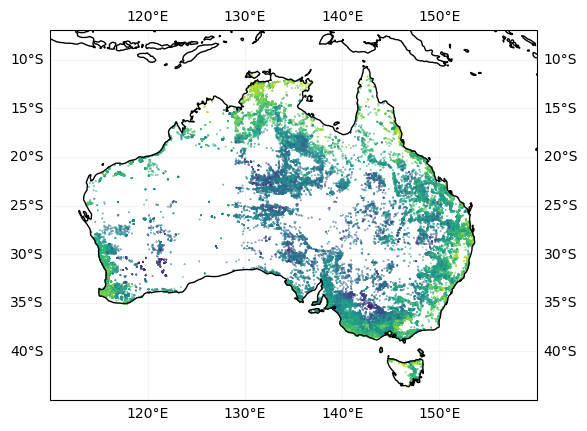

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 160, -45, -7], crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', zorder=10)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.125)
ax.scatter(boredata['Longitude'],boredata['Latitude'], c=np.log(boredata['Recharge_rate']), s=0.1)
plt.show()